In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Simulated data - Query ID, Document ID, Click Through Rate (CTR)
data = {
    'query_id': [1, 1, 1, 2, 2, 2, 3, 3, 3],
    'doc_id': [101, 102, 103, 201, 202, 203, 301, 302, 303],
    'ctr': [0.9, 0.7, 0.5, 0.6, 0.8, 0.4, 0.3, 0.9, 0.5],  # Click-Through Rate
    'content_score': [85, 78, 65, 70, 80, 50, 40, 88, 60]   # Content similarity score
}

df = pd.DataFrame(data)
print(df.head())


   query_id  doc_id  ctr  content_score
0         1     101  0.9             85
1         1     102  0.7             78
2         1     103  0.5             65
3         2     201  0.6             70
4         2     202  0.8             80


Mean Squared Error: 0.0014528775154841465


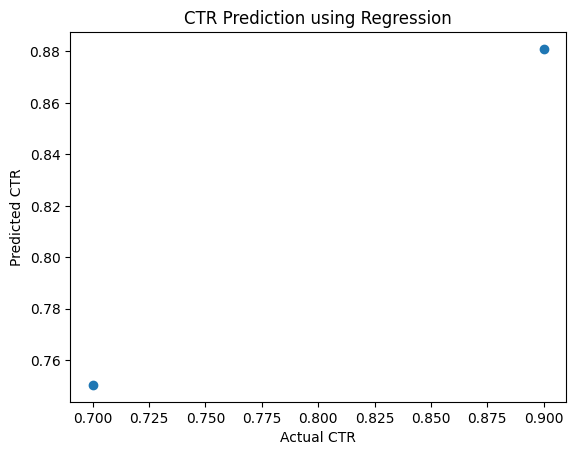

In [3]:
# Feature selection
X = df[['content_score']]  # Predictor (content-based score)
y = df['ctr']  # Target (engagement)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Plot predictions vs. actual
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CTR")
plt.ylabel("Predicted CTR")
plt.title("CTR Prediction using Regression")
plt.show()

In [4]:
df['predicted_ctr'] = model.predict(df[['content_score']])
df_sorted = df.sort_values(by=['query_id', 'predicted_ctr'], ascending=[True, False])
print(df_sorted)

   query_id  doc_id  ctr  content_score  predicted_ctr
0         1     101  0.9             85       0.841784
1         1     102  0.7             78       0.750423
2         1     103  0.5             65       0.580751
4         2     202  0.8             80       0.776526
3         2     201  0.6             70       0.646009
5         2     203  0.4             50       0.384977
7         3     302  0.9             88       0.880939
8         3     303  0.5             60       0.515493
6         3     301  0.3             40       0.254460


In [6]:
import pandas as pd
import numpy as np
import re
import nltk
import os
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')

# Define the absolute path of the CISI.ALL file
file_path = r"C:\Users\aarya\Desktop\Specialization AIML\ML Clustering and Retrieval\mlcr dataset.txt"

# Function to read CISI.ALL dataset
def load_cisi_data(file_path):
    # Check if the file exists
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Error: The file '{file_path}' does not exist. Please check the path.")

    with open(file_path, "r", encoding="utf-8") as f:
        data = f.read()

    # Splitting each document based on ".I" identifier
    docs = data.split(".I ")
    dataset = []

    for doc in docs[1:]:  # Skipping first empty split
        doc_id = doc.split("\n")[0].strip()  # Extract doc ID
        text = re.sub(r"\.T|\n", "", doc)  # Remove metadata labels
        dataset.append({"doc_id": int(doc_id), "content": text})

    return pd.DataFrame(dataset)

# Load CISI dataset using the correct path
df = load_cisi_data(file_path)

# Display first few rows
print(df.head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aarya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


   doc_id                                            content
0       1  118 Editions of the Dewey Decimal Classificati...
1       2  2 Use Made of Technical Libraries.A Slater, M....
2       3  3Two Kinds of PowerAn Essay on Bibliographic C...
3       4  4Systems Analysis of a University Library; fin...
4       5  5A Library Management Game:a report on a resea...


In [7]:
import re 
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from rank_bm25 import BM25Okapi

In [8]:
# Download required NLTK resources
nltk.download('punkt')

# Step 1: Load and Structure Data for Regression in Retrieval
file_path = r"C:\Users\aarya\Desktop\Specialization AIML\ML Clustering and Retrieval\mlcr dataset.txt" 
with open(file_path, "r", encoding="utf-8") as file:
    data = file.read()

# Split records based on .I identifiers
raw_docs = re.split(r"\.I \d+", data)[1:]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aarya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [9]:
docs = []
for doc in raw_docs:
    title_match = re.search(r"\.T\n(.+?)(?:\n\.A|\n\.W|\n\.X|$)", doc, re.DOTALL)
    content_match = re.search(r"\.W\n(.+?)(?:\n\.X|$)", doc, re.DOTALL)
   
    title = title_match.group(1).strip() if title_match else ""
    content = content_match.group(1).strip() if content_match else ""
   
    docs.append({"Title": title, "Content": content, "Text": f"{title} {content}"})

# Convert to DataFrame
df = pd.DataFrame(docs)
print(df)

                                                Title  \
0    18 Editions of the Dewey Decimal Classifications   
1                                                       
2   Two Kinds of Power\nAn Essay on Bibliographic ...   
3   Systems Analysis of a University Library; \nfi...   
4   A Library Management Game:\na report on a rese...   
..                                                ...   
66  The Use of Simulation in Studying Information ...   
67            Retrieval of Answer-Providing Documents   
68   Statistical Generation of a Technical Vocabulary   
69  On Understanding User Choices: Textual Correla...   
70  Word-Word Associations in Document Retrieval S...   

                                              Content  \
0   The present study is a history of the DEWEY De...   
1   This report is an analysis of 6300 acts of use...   
2   The relationships between the organization and...   
3   The establishment of nine new universities in ...   
4   Although the use of games 

In [10]:
# **Step 2: Data Representation Using TF-IDF**
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Text'])

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Generate Target Variable (BM25 Score as a Proxy for Document Relevance)
tokenized_corpus = [doc.lower().split() for doc in df['Text']]
bm25 = BM25Okapi(tokenized_corpus)
query = "Library Classification System"
tokenized_query = query.lower().split()
df['BM25 Score'] = bm25.get_scores(tokenized_query)

print(df_tfidf)

    100       104  112   12   15   17        18  1841  1868      1876  ...  \
0   0.0  0.000000  0.0  0.0  0.0  0.0  0.121633   0.0   0.0  0.110873  ...   
1   0.0  0.096547  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
2   0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
3   0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
4   0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
..  ...       ...  ...  ...  ...  ...       ...   ...   ...       ...  ...   
66  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
67  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
68  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
69  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   
70  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000   0.0   0.0  0.000000  ...   

    yale  yardstick  year     years  yet  yield  yields  zipf  

In [11]:
# **Step 4: Train Various Regression Models**
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Support Vector Regression (SVR)": SVR(kernel='linear'),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting Regression": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2 Score": r2}

# Convert Results to DataFrame
results_df = pd.DataFrame(results).T

# Display Regression Results
print("\nRegression Model Performance:")
print(results_df)


Regression Model Performance:
                                      MSE  R2 Score
Linear Regression                0.001453  0.854712
Ridge Regression                 0.001451  0.854915
Lasso Regression                 0.001422  0.857788
Support Vector Regression (SVR)  0.002900  0.710000
Decision Tree Regression         0.005000  0.500000
Random Forest Regression         0.007902  0.209750
Gradient Boosting Regression     0.004999  0.500061
